In [1]:
from CADETProcess.optimization import OptimizationProblem
from CADETProcess.processModel import Inlet, MCT, Outlet
from CADETProcess.optimization import SLSQP, U_NSGA3, Pathos, Joblib, COBYLA, TrustConstr
from CADETProcess.processModel import ComponentSystem,MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet
from scipy.optimize import minimize

import logging

from IPython import display

from utils import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
df = pd.read_csv('Poplar_02_L1_M3_second_Branch_velocity_change.csv', sep=';')
data = df.to_numpy()
xi = df.columns.values[1:6]
xi = [float(x) for x in xi]

t = data[2:,0]

In [3]:
xi

[0.0, 14.28070634, 28.32597297, 42.47523083, 56.61385665]

In [4]:
t

array([ 10.,  15.,  20.,  25.,  30.,  35.,  40.,  45.,  50.,  55.,  60.,
        65.,  70.,  75.,  80.,  85.,  90.,  95., 100., 105., 110., 115.,
       120., 125., 130., 135., 140., 145.])

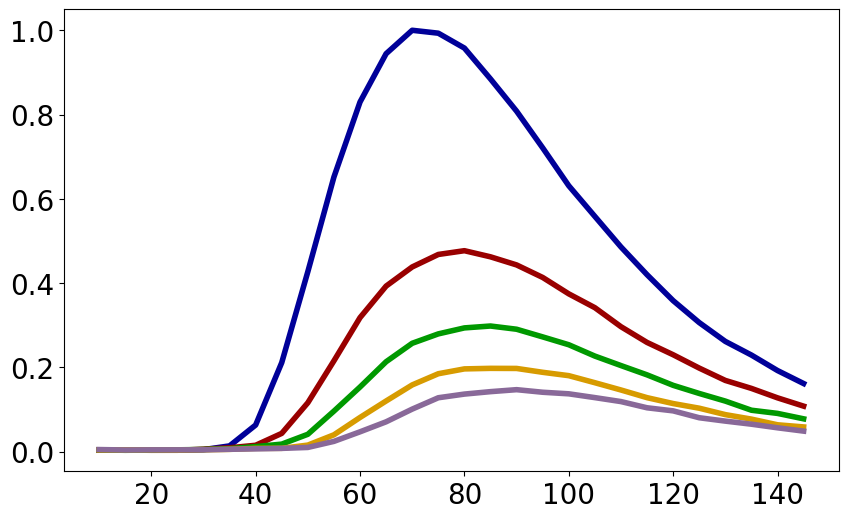

In [5]:
orig_exp_data = data[2:,1:6]
exp_data = data[2:,1:6]*np.exp(-0.00056729782996132*60*t.reshape(len(t),1))
exp_data = exp_data/np.max(exp_data)
plt.plot(t, exp_data)

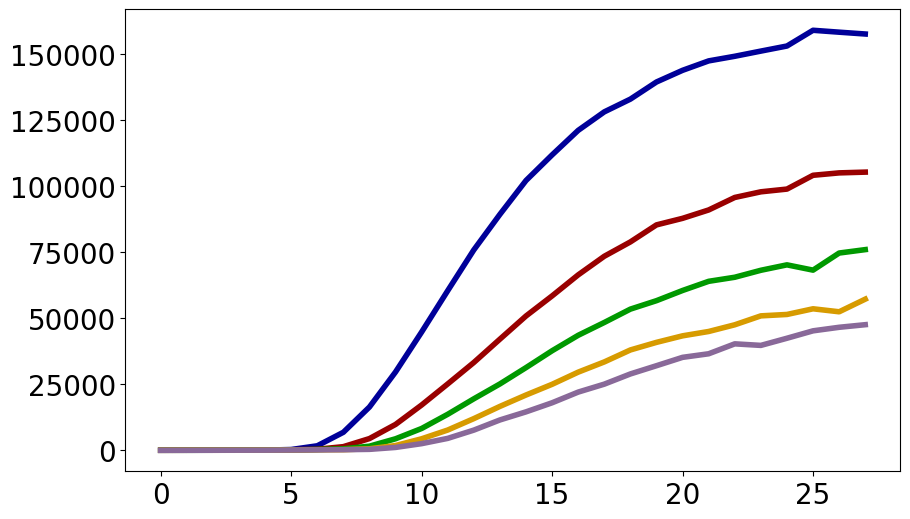

In [6]:
plt.plot(orig_exp_data)

In [7]:
def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct1_e12 = x[1]
    p_mct1_e21 = x[2]
    p_mct1_e23 = x[3]
    p_mct2_e12 = x[4]
    p_mct3_e12 = x[5]
    p_mct4_e12 = x[6]
    p_mct1_disp = x[7]
    p_mct3_disp = x[8]
    p_mct4_disp = x[9]
    p_total_porosity = x[10]
    p_col_dispersion = x[11]
    p_col_len = x[12]
    p_t0 = x[13]
    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct1 = MCT(component_system, nchannel=3, name='mct1')
    mct2 = MCT(component_system, nchannel=2, name='mct2')
    mct3 = MCT(component_system, nchannel=2, name='mct3')
    mct4 = MCT(component_system, nchannel=2, name='mct4')
    mct5 = MCT(component_system, nchannel=2, name='mct5')
    outlet = Outlet(component_system, name='outlet')

    leaf.discretization.ncol = 20
    mct1.discretization.ncol = 20
    mct2.discretization.ncol = 20
    mct3.discretization.ncol = 20
    mct4.discretization.ncol = 20


    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)

    mct1.bulk_reaction_model = reaction_system
    mct2.bulk_reaction_model = reaction_system
    mct3.bulk_reaction_model = reaction_system
    mct4.bulk_reaction_model = reaction_system


    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct1)
    mct_flow_sheet.add_unit(mct2)
    mct_flow_sheet.add_unit(mct3)
    mct_flow_sheet.add_unit(mct4)
    mct_flow_sheet.add_unit(outlet)

    v_lrmp = 4e-05

    leaf.total_porosity = p_total_porosity
    leaf.length = p_col_len
    leaf.diameter = x[0]/v_lrmp #np.sqrt(1/np.pi)
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct1, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct1, mct2, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct2, mct3, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct3, mct4, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct4, outlet, origin_port = 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct1.length =  xi[1]/1000
    mct2.length =  xi[2]/1000-xi[1]/1000
    mct3.length =  xi[3]/1000-xi[2]/1000
    mct4.length =  xi[4]/1000-xi[3]/1000
    
    mct1.channel_cross_section_areas = [1,1,1] 
    mct2.channel_cross_section_areas = [1,1] 
    mct3.channel_cross_section_areas = [1,1] 
    mct4.channel_cross_section_areas = [1,1] 
    
    mct1.axial_dispersion = p_mct1_disp
    mct2.axial_dispersion = 0
    mct3.axial_dispersion = p_mct3_disp
    mct4.axial_dispersion = p_mct4_disp
    
    mct1.solution_recorder.write_solution_bulk = 1
    mct2.solution_recorder.write_solution_bulk = 1
    mct3.solution_recorder.write_solution_bulk = 1
    mct4.solution_recorder.write_solution_bulk = 1

    mct1.exchange_matrix = np.array([
                                    [[0.0], [p_mct1_e12], [0.0]],
                                    [[p_mct1_e21], [0.0], [p_mct1_e23]],
                                    [[0.0], [0.0], [0.0]]
                                    ])
    
    mct2.exchange_matrix =np.array([
                                    [[0.0], [p_mct2_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct3.exchange_matrix =np.array([
                                    [[0.0], [p_mct3_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct4.exchange_matrix =np.array([
                                    [[0.0], [p_mct4_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])


    process.cycle_time = 60*t[-1]

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

In [8]:
xi

[0.0, 14.28070634, 28.32597297, 42.47523083, 56.61385665]

In [9]:
xi[-1]/1000-xi[4]/1000

0.0

In [10]:
# Define min and max values for each parameter

param_bounds = {
    'volumetric_flow_rate_const': (1e-05, 2e-04),  # log-scaling
    'mct1_e12': (1e-10, 20),  # log-scaling
    'mct1_e21': (1e-10, 20),  # log-scaling
    'mct1_e23': (1e-10, 20),  # log-scaling
    'mct2_e12': (1e-10, 20),  # log-scaling
    'mct3_e12': (1e-10, 20),  # log-scaling
    'mct4_e12': (1e-10, 20),  # log-scaling
    'disp1': (1e-16, 1e-3),   # log-scaling
    'disp3': (1e-10, 1e-2),   # log-scaling
    'disp4': (1e-10, 1e-2),   # log-scaling
    'total_porosity': (0.1, 0.99),     # linear scaling
    'col_dispersion': (1e-07, 1e-06),  # log-scaling
    'col_len': (0.01, 0.3),            # linear scaling
    't0': (0.1, 2),                    # linear scaling
}



def analyze_parameters(norm_param_values, param_bounds=param_bounds):
    """
    Analyze parameters and print their names, denormalized values, and normalized values.

    Args:
        norm_param_values (list): Normalized parameter values (0-1 range).
        param_bounds (dict): Dictionary with parameter names as keys and boundary tuples as values.

    Returns:
        None: Prints the analysis.
    """
    print(f"{'Name':<30}{'Denormalized Value':<20}{'Normalized Value':<10}")
    print("-" * 65)

    # Denormalize parameters
    param_values = denormalize_parameters(norm_param_values)

    for i, (name, bounds) in enumerate(param_bounds.items()):
        value = param_values[i]
        norm_param = norm_param_values[i]

        print(f"{name:<30}{value:<20.8e}{norm_param:<10.2f}")

def normalize_parameters(x):
    normalized_x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # If the range is large, use log scaling
            norm_param = (np.log(x[i]) - np.log(min_val)) / (np.log(max_val) - np.log(min_val))
        else:  # For compact ranges, use min-max scaling
            norm_param = (x[i] - min_val) / (max_val - min_val)
        
        normalized_x.append(norm_param)
    
    return np.array(normalized_x)

def denormalize_parameters(norm_x):
    x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # Log scaling for large ranges
            param_value = np.exp(norm_x[i] * (np.log(max_val) - np.log(min_val)) + np.log(min_val))
        else:  # Min-max scaling for compact ranges
            param_value = norm_x[i] * (max_val - min_val) + min_val
        
        x.append(param_value)
    
    return np.array(x)

In [11]:
[x / 1000 for x in xi]

[0.0, 0.01428070634, 0.02832597297, 0.04247523083, 0.05661385665]

In [12]:
xi[1]/1000, xi[2]/1000-xi[1]/1000 , xi[3]/1000-xi[2]/1000, xi[4]/1000-xi[3]/1000,xi[-1]/1000-xi[4]/1000

(0.01428070634, 0.014045266629999999, 0.014149257860000004, 0.01413862582, 0.0)

In [13]:
(xi[1]/1000)+(xi[2]/1000-xi[1]/1000)+(xi[3]/1000-xi[2]/1000)+(xi[4]/1000-xi[3]/1000)+(xi[-1]/1000-xi[4]/1000)
    

0.05661385665

In [14]:
lenghts = [x / 1000 for x in xi]

eval_location1 = lenghts[0:1] 
eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
eval_location4 = list(np.array(lenghts[3:])-lenghts[3])



eval_location1,eval_location2, eval_location3, eval_location4

([0.0],
 [np.float64(0.0)],
 [np.float64(0.0)],
 [np.float64(0.0), np.float64(0.01413862582)])

In [15]:
lenghts[0:1],lenghts[1:3], lenghts[3:4], lenghts[4:]

([0.0], [0.01428070634, 0.02832597297], [0.04247523083], [0.05661385665])

In [16]:
def mct_obj(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]



    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:])-lenghts[3])


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)
    
    res=(calc_data.ravel()-exp_data.ravel())**2
    res=np.sum(res)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, res)

    return res

def mct_obj_res(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]



    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:])-lenghts[3])


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)
    


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)
    
    res=(calc_data.ravel()-exp_data.ravel())
    ssq=np.sum(res**2)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, res)

    return res

def mct_full_result(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)
    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]



    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:])-lenghts[3])


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)
    
    
    plot_fit(time_new, calc_data, exp_data)

    return calc_data

In [17]:
def plot_fit(time, calc_data, experimental_data):

    display.clear_output(wait=True)

    calc_data = calc_data/np.max(calc_data)
    
    res=np.sum(((calc_data.ravel()-exp_data.ravel())**2).reshape(28,5),axis=1)
    

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(121)
    ax1.plot(time,calc_data[:,0:1], label="mct1", color='k', linewidth=1)
    ax1.plot(time,calc_data[:,1:2], label="mct2", color='r', linewidth=1)
    ax1.plot(time,calc_data[:,2:3], label="mct3", color='b', linewidth=1)
    ax1.plot(time,calc_data[:,3:4], label="mct4", color='g', linewidth=1)
    ax1.plot(time,calc_data[:,4:], label="mct5", color='y', linewidth=1)
    ax1.plot(time,res, label="res", color='b')
    ax1.plot(time,experimental_data,'.')
    
    #ax1.legend()

    # ax2 = fig.add_subplot(132)

    # ax3 = fig.add_subplot(133)
    # ax3.plot(self.ssq_list, label=ssq)
    # v_text='v:'+str(v)
    # ax3.set_title(v_text)
    # ax3.legend()

    display.display(fig)
    plt.close(fig)
    

In [23]:
simulator = Cadet()    
simulator.use_dll = True
simulator.time_resolution = 60
# optimization_problem.add_objective(
#     mct_obj,
#     n_objectives=1,
# )


In [19]:
normalize_parameters([8.46147043e-05, 8.79826751e-03, 6.59526351e-03,
 1.45144017e-03, 1.28111262e-03, 1.21724995e-03, 1.04609671e-03,
 1.50470319e-03, 2.69516532e-08, 3.16227766e-16, 3.56134396e-07,
 2.11367047e-06, 1.05671551e-06, 4.78138065e-01, 7.13260810e-07,
 1.75227068e-01, 1.75552387e+00] )

array([ 0.39270897,  0.70297992,  0.69190438,  0.63372977,  0.6289327 ,
        0.62696761,  0.62114443,  1.01365006,  0.30382318, -0.6875    ,
       -0.11235915,  2.23741163, -0.03447911,  0.19902003])

In [74]:
analyze_parameters([0.35307084, 0.68079411, 0.63950353, 0.6255375 , 0.6400871 ,
       0.64628126, 0.64368471, 0.67228701, 0.37061246, 0.22291454,
       0.51082819, 0.51642038, 0.47939402, 0.96220357])



# Parameter 0: ±5.264683258748181%
# Parameter 1: ±1.4962649730106239%
# Parameter 2: ±2.429817420639929%
# Parameter 3: ±0.6339121869290397%
# Parameter 4: ±0.6091502291263101%
# Parameter 5: ±0.8207813219966454%
# Parameter 6: ±1.0662986145289504%
# Parameter 7: ±5.919199776962279%
# Parameter 8: ±3.177209195442856%
# Parameter 9: ±8.997888113415902%
# Parameter 10: ±71436.79985203421%
# Parameter 11: ±142310.39809226888%
# Parameter 12: ±62768.40806235826%
# Parameter 13: ±0.0%

Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    7.70834596e-05      0.35      
mct1_e12                      4.93940524e-03      0.68      
mct1_e21                      1.68674167e-03      0.64      
mct1_e23                      1.17278405e-03      0.63      
mct2_e12                      1.71255101e-03      0.64      
mct3_e12                      2.01207379e-03      0.65      
mct4_e12                      1.88061638e-03      0.64      
disp1                         5.49200761e-08      0.67      
disp3                         9.22358342e-08      0.37      
disp4                         6.07178409e-09      0.22      
total_porosity                5.54637089e-01      0.51      
col_dispersion                5.64778342e-07      0.52      
col_len                       1.49024266e-01      0.48      
t0                            1.92818678e+00      0.96      


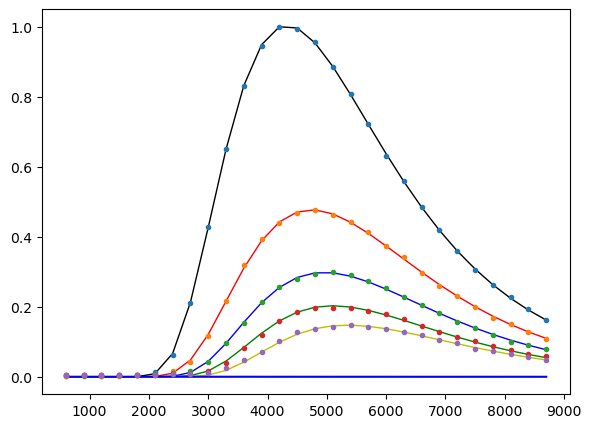

[7.70834596e-05 4.93940524e-03 1.68674167e-03 1.17278405e-03
 1.71255101e-03 2.01207379e-03 1.88061638e-03 5.49200761e-08
 9.22358342e-08 6.07178409e-09 5.54637089e-01 5.64778342e-07
 1.49024266e-01 1.92818678e+00] 0.0018765451579248389


np.float64(0.0018765451579248389)

In [70]:
 mct_obj([0.35307084, 0.68079411, 0.63950353, 0.6255375 , 0.6400871 ,
       0.64628126, 0.64368471, 0.67228701, 0.37061246, 0.22291454,
       0.51082819, 0.51642038, 0.47939402, 0.96220357]
)

In [ ]:
Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    7.70834596e-05      0.35      
mct1_e12                      4.93940524e-03      0.68      
mct1_e21                      1.68674167e-03      0.64      
mct1_e23                      1.17278405e-03      0.63      
mct2_e12                      1.71255101e-03      0.64      
mct3_e12                      2.01207379e-03      0.65      
mct4_e12                      1.88061638e-03      0.64      
disp1                         5.49200761e-08      0.67      
disp3                         9.22358342e-08      0.37      
disp4                         6.07178409e-09      0.22      
total_porosity                5.54637089e-01      0.51      
col_dispersion                5.64778342e-07      0.52      
col_len                       1.49024266e-01      0.48      
t0                            1.92818678e+00      0.96      

Parameter 0: ±5.264683258748181%
Parameter 1: ±1.4962649730106239%
Parameter 2: ±2.429817420639929%
Parameter 3: ±0.6339121869290397%
Parameter 4: ±0.6091502291263101%
Parameter 5: ±0.8207813219966454%
Parameter 6: ±1.0662986145289504%
Parameter 7: ±5.919199776962279%
Parameter 8: ±3.177209195442856%
Parameter 9: ±8.997888113415902%
Parameter 10: ±71436.79985203421%
Parameter 11: ±142310.39809226888%
Parameter 12: ±62768.40806235826%
Parameter 13: ±0.0%

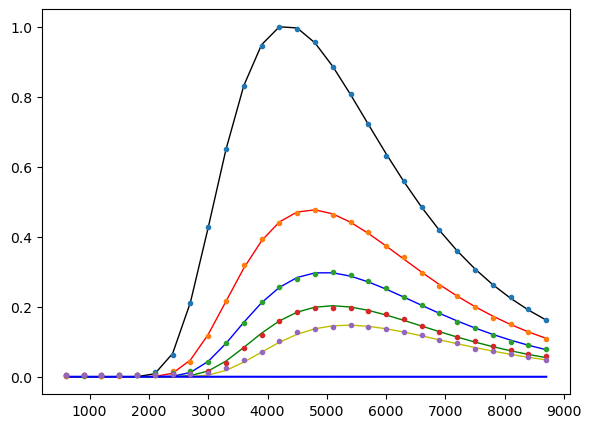

[7.70834600e-05 4.93940491e-03 1.68674179e-03 1.17278409e-03
 1.71255091e-03 2.01207395e-03 1.88061636e-03 5.49200809e-08
 9.22358414e-08 6.07178408e-09 5.54637085e-01 5.64778340e-07
 1.49024265e-01 1.92819829e+00] 0.0018765433436665458
CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
iters: 234 func evals: 7627 grad evals: 263
||proj grad||_inf: 0.0009394856712565583


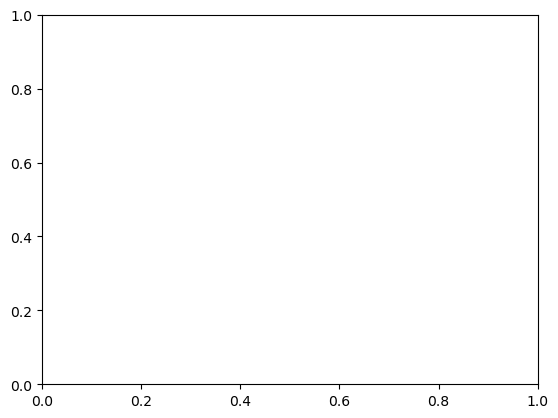

In [55]:
x0 = ([0.4152671 , 0.68941387, 0.67832011, 0.62252204, 0.61804078,
       0.61382378, 0.6350707 , 0.62736511, 0.55006044, 0.12699043,
       0.46085008, 0.49419973, 0.50410273, 0.86227505])




# Initialize the plot
fig, ax = plt.subplots()

fig.canvas.draw()
display.display(fig)

result_nm = minimize(
    fun=mct_obj,
    x0=x0,
    method='L-BFGS-B',
    jac='3-point',                      # better: pass a callable analytic gradient
    bounds=14 * ((0, 1),),
    options={
        'maxiter': 5000,
        'ftol': 1e-9,                   # function tolerance (strict)
        'gtol': 1e-8,                   # projected gradient tolerance (strict)
        'maxls': 50,                    # more line-search steps if needed
        'eps': 1e-6,                    # finite-diff step (small!)
        # do NOT set 'finite_diff_rel_step' at the same time as 'eps'
    }
)
print(result_nm.message)
print("iters:", result_nm.nit, "func evals:", result_nm.nfev, "grad evals:", result_nm.njev)
print("||proj grad||_inf:", float(np.abs(result_nm.jac).max()))



In [62]:
result_nm.x

array([0.35307084, 0.68079411, 0.63950353, 0.6255375 , 0.6400871 ,
       0.64628126, 0.64368471, 0.67228701, 0.37061246, 0.22291454,
       0.51082819, 0.51642038, 0.47939402, 0.96220357])

In [ ]:
Parameter 0: ±5.264683258748181%
Parameter 1: ±1.4962649730106239%
Parameter 2: ±2.429817420639929%
Parameter 3: ±0.6339121869290397%
Parameter 4: ±0.6091502291263101%
Parameter 5: ±0.8207813219966454%
Parameter 6: ±1.0662986145289504%
Parameter 7: ±5.919199776962279%
Parameter 8: ±3.177209195442856%
Parameter 9: ±8.997888113415902%
Parameter 10: ±71436.79985203421%
Parameter 11: ±142310.39809226888%
Parameter 12: ±62768.40806235826%
Parameter 13: ±0.0%

Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
volumetric_flow_rate_const    7.70834596e-05      0.35      
mct1_e12                      4.93940524e-03      0.68      
mct1_e21                      1.68674167e-03      0.64      
mct1_e23                      1.17278405e-03      0.63      
mct2_e12                      1.71255101e-03      0.64      
mct3_e12                      2.01207379e-03      0.65      
mct4_e12                      1.88061638e-03      0.64      
disp1                         5.49200761e-08      0.67      
disp3                         9.22358342e-08      0.37      
disp4                         6.07178409e-09      0.22      
total_porosity                5.54637089e-01      0.51      
col_dispersion                5.64778342e-07      0.52      
col_len                       1.49024266e-01      0.48      
t0                            1.92818678e+00      0.96      

In [68]:


# Updated calculation with new parameters and uncertainties
import numpy as np
import pandas as pd
from math import sqrt, exp

# =====================
# Denormalized parameters (this run)
# =====================
Q_m3_s = 7.70834596e-05   # volumetric_flow_rate_const  [m^3/s]

# relative uncertainties (as fractions, not %)
rel_unc = {
    "Q":        0.05264683258748181,  # Param 0
    "MCT1_e12": 0.014962649730106239,  # Param 1
    "MCT1_e21": 0.02429817420639929,  # Param 2
    "MCT1_e23": 0.0063391218692903975,  # Param 3
    "MCT2_e12": 0.006091502291263101,  # Param 4
    "MCT3_e12": 0.008207813219966454,    # Param 5
    "MCT4_e12": 0.010662986145289504,  # Param 6
}

# Exchange rates (1/s) → convert to 1/min
rates_s = {
    "MCT1": {"model": "M13", "e12": 4.93940524e-03, "e21": 1.68674167e-03, "e23": 1.17278405e-03},
    "MCT2": {"model": "M02", "e12": 1.71255101e-03},
    "MCT3": {"model": "M02", "e12": 2.01207379e-03},
    "MCT4": {"model": "M02", "e12": 1.88061638e-03},
}
rates_min = {
    k: {**v, **{ek: ev*60.0 for ek, ev in v.items() if ek.startswith("e")}}
    for k, v in rates_s.items()
}

# All areas are 1 m^2 (superficial velocity). If you later want interstitial:
use_interstitial_velocity = False
total_porosity = 5.10156571e-01  # used only if you set use_interstitial_velocity=True

# Axial positions (mm) → 4 units
x_mm = np.array([0.0, 14.28070634, 28.32597297, 42.47523083, 56.61385665])
Ncells = 20

# =====================
# Helpers
# =====================
def velocity_mm_per_min(Q_m3_s, area_m2=1.0, porosity=None):
    """Superficial u = Q/A; interstitial u = Q/(A*ε) if porosity is given."""
    denom = area_m2 if porosity is None else (area_m2 * porosity)
    u_m_s = Q_m3_s / denom
    return u_m_s * 1000.0 * 60.0  # mm/min

def rel_unc_velocity(rel_Q, rel_A=0.0, rel_porosity=0.0, use_interstitial=False):
    """Relative uncertainty for u. If interstitial, include porosity."""
    if use_interstitial:
        return sqrt(rel_Q**2 + rel_A**2 + rel_porosity**2)
    return sqrt(rel_Q**2 + rel_A**2)

# =====================
# Build units
# =====================
units = []
for i, name in enumerate(["MCT1","MCT2","MCT3","MCT4"]):
    L_mm = float(x_mm[i+1] - x_mm[i])
    dx_mm = L_mm / Ncells
    units.append({"name": name, "L_mm": L_mm, "dx_mm": dx_mm})

# =====================
# Core loop
# =====================
rows = []
for u in units:
    name = u["name"]
    L_mm = u["L_mm"]
    dx_mm = u["dx_mm"]

    # Velocity & its relative uncertainty
    if use_interstitial_velocity:
        u_mm_min = velocity_mm_per_min(Q_m3_s, 1.0, total_porosity)
        u_rel = rel_unc_velocity(rel_unc["Q"], 0.0, rel_unc["porosity"], True)
    else:
        u_mm_min = velocity_mm_per_min(Q_m3_s, 1.0, None)
        u_rel = rel_unc_velocity(rel_unc["Q"], 0.0, 0.0, False)

    # Theta [1/mm] and its relative uncertainty
    p = rates_min[name]
    if p["model"] == "M13":
        e12, e21, e23 = p["e12"], p["e21"], p["e23"]
        theta = (e12 * e23) / (u_mm_min * (e21 + e23))

        # rel uncertainty parts for M13
        # rel(e12), rel(e23), rel(u), and rel(e21+e23) from independent e21, e23
        rel_e12 = rel_unc["MCT1_e12"]
        rel_e21 = rel_unc["MCT1_e21"]
        rel_e23 = rel_unc["MCT1_e23"]
        sigma_sum = sqrt((rel_e21*e21)**2 + (rel_e23*e23)**2)
        rel_sum = sigma_sum / (e21 + e23)

        rel_theta = sqrt(rel_e12**2 + rel_e23**2 + u_rel**2 + rel_sum**2)

    else:  # M02
        e12 = p["e12"]
        theta = e12 / u_mm_min
        rel_theta = sqrt(rel_unc[f"{name}_e12"]**2 + u_rel**2)

    # === Loss metrics ===
    # Per cell
    L_cell = 1.0 - exp(-theta * dx_mm)
    # Uncertainty: dL/dθ = dx * exp(-θ dx)
    sigma_L_cell = exp(-theta * dx_mm) * dx_mm * (theta * rel_theta)

    # Per mm (average from cell)
    L_per_mm_avg = L_cell / dx_mm
    sigma_L_per_mm_avg = sigma_L_cell / dx_mm

    # Over unit (continuous)
    L_total_cont = 1.0 - exp(-theta * L_mm)
    sigma_L_total_cont = exp(-theta * L_mm) * L_mm * (theta * rel_theta)

    # Over unit (discrete compounding)
    L_total_disc = 1.0 - (1.0 - L_cell)**Ncells
    d_disc_d_Lcell = Ncells * (1.0 - L_cell)**(Ncells - 1)
    sigma_L_total_disc = d_disc_d_Lcell * sigma_L_cell

    rows.append({
        "Unit": name,
        "Length_mm": L_mm,
        "Cell_length_mm": dx_mm,
        "Velocity_mm_per_min": u_mm_min,
        "Velocity_rel_unc_%": u_rel * 100.0,
        "Theta_1_per_mm": theta,
        "Theta_rel_unc_%": rel_theta * 100.0,

        # Per cell
        "Loss_per_cell_frac": L_cell,
        "Loss_per_cell_unc_abs": sigma_L_cell,

        # Per mm (avg from cell)
        "Loss_per_mm_avg_frac": L_per_mm_avg,
        "Loss_per_mm_avg_unc_abs": sigma_L_per_mm_avg,

        # Unit totals
        "Total_loss_cont_frac": L_total_cont,
        "Total_loss_cont_unc_abs": sigma_L_total_cont,
        "Total_loss_disc_frac": L_total_disc,
        "Total_loss_disc_unc_abs": sigma_L_total_disc,
    })

df = pd.DataFrame(rows).set_index("Unit")

# ---- % columns & relative-uncertainty columns (easier to read) ----
df["Loss_per_cell_%"] = 100.0 * df["Loss_per_cell_frac"]
df["Loss_per_cell_unc_abs_%"] = 100.0 * df["Loss_per_cell_unc_abs"]
df["Loss_per_cell_rel_unc_%"] = 100.0 * (df["Loss_per_cell_unc_abs"] / np.maximum(df["Loss_per_cell_frac"], 1e-300))

df["Loss_per_mm_avg_%"] = 100.0 * df["Loss_per_mm_avg_frac"]
df["Loss_per_mm_avg_unc_abs_%"] = 100.0 * df["Loss_per_mm_avg_unc_abs"]
df["Loss_per_mm_avg_rel_unc_%"] = 100.0 * (df["Loss_per_mm_avg_unc_abs"] / np.maximum(df["Loss_per_mm_avg_frac"], 1e-300))

df["Total_loss_cont_%"] = 100.0 * df["Total_loss_cont_frac"]
df["Total_loss_cont_unc_abs_%"] = 100.0 * df["Total_loss_cont_unc_abs"]
df["Total_loss_cont_rel_unc_%"] = 100.0 * (df["Total_loss_cont_unc_abs"] / np.maximum(df["Total_loss_cont_frac"], 1e-300))

df["Total_loss_disc_%"] = 100.0 * df["Total_loss_disc_frac"]
df["Total_loss_disc_unc_abs_%"] = 100.0 * df["Total_loss_disc_unc_abs"]
df["Total_loss_disc_rel_unc_%"] = 100.0 * (df["Total_loss_disc_unc_abs"] / np.maximum(df["Total_loss_disc_frac"], 1e-300))

# ---- display order & rounding ----
order = [
    "Length_mm","Cell_length_mm",
    "Velocity_mm_per_min","Velocity_rel_unc_%",
    #"Theta_1_per_mm","Theta_rel_unc_%",

    "Loss_per_cell_frac","Loss_per_cell_%","Loss_per_cell_unc_abs_%","Loss_per_cell_rel_unc_%",
    "Loss_per_mm_avg_frac","Loss_per_mm_avg_%","Loss_per_mm_avg_unc_abs_%","Loss_per_mm_avg_rel_unc_%",
    #"Total_loss_cont_frac","Total_loss_cont_%","Total_loss_cont_unc_abs_%","Total_loss_cont_rel_unc_%",
    #"Total_loss_disc_frac","Total_loss_disc_%","Total_loss_disc_unc_abs_%","Total_loss_disc_rel_unc_%",
]
df = df[order]

round_map = {
    "Length_mm": 4, "Cell_length_mm": 4,
    "Velocity_mm_per_min": 4, "Velocity_rel_unc_%": 3,
    #"Theta_1_per_mm": 6, "Theta_rel_unc_%": 3,

    "Loss_per_cell_frac": 6, "Loss_per_cell_%": 4, "Loss_per_cell_unc_abs_%": 4, "Loss_per_cell_rel_unc_%": 3,
    "Loss_per_mm_avg_frac": 6, "Loss_per_mm_avg_%": 4, "Loss_per_mm_avg_unc_abs_%": 4, "Loss_per_mm_avg_rel_unc_%": 3,
    #"Total_loss_cont_frac": 6, "Total_loss_cont_%": 4, "Total_loss_cont_unc_abs_%": 4, "Total_loss_cont_rel_unc_%": 3,
    #"Total_loss_disc_frac": 6, "Total_loss_disc_%": 4, "Total_loss_disc_unc_abs_%": 4, "Total_loss_disc_rel_unc_%": 3,
}
for c, r in round_map.items():
    if c in df.columns:
        df[c] = df[c].round(r)

df

,Length_mm,Cell_length_mm,Velocity_mm_per_min,Velocity_rel_unc_%,Loss_per_cell_frac,Loss_per_cell_%,Loss_per_cell_unc_abs_%,Loss_per_cell_rel_unc_%,Loss_per_mm_avg_frac,Loss_per_mm_avg_%,Loss_per_mm_avg_unc_abs_%,Loss_per_mm_avg_rel_unc_%
Unit,,,,,,,,,,,,
MCT1,14.2807,0.7140,4.625,5.265,0.018590,1.8590,0.1050,5.646,0.026036,2.6036,0.1470,5.646
MCT2,14.0453,0.7023,4.625,5.265,0.015481,1.5481,0.0814,5.259,0.022044,2.2044,0.1159,5.259
MCT3,14.1493,0.7075,4.625,5.265,0.018297,1.8297,0.0966,5.279,0.025863,2.5863,0.1365,5.279
MCT4,14.1386,0.7069,4.625,5.265,0.017099,1.7099,0.0911,5.325,0.024188,2.4188,0.1288,5.325


In [28]:
x = [
    0.0,
    14.28070634,
    28.32597297,
    42.47523083,
    56.61385665,
    70.76956106,
    84.72303724,
]

deltas = [curr - prev for prev, curr in zip(x, x[1:])]
print(deltas)

[14.28070634, 14.045266629999999, 14.149257860000002, 14.138625820000001, 14.155704409999998, 13.953476179999996]


In [24]:
def plot_pretty(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,60*5)

    mct1 = process.flow_sheet.units[2]
    mct2 = process.flow_sheet.units[3]
    mct3 = process.flow_sheet.units[4]
    mct4 = process.flow_sheet.units[5]



    lenghts = [x / 1000 for x in xi]

    eval_location1 = lenghts[0:1] 
    eval_location2 = list(np.array(lenghts[1:2])-lenghts[1])
    eval_location3 = list(np.array(lenghts[2:3])-lenghts[2])
    eval_location4 = list(np.array(lenghts[3:])-lenghts[3])


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct1, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.atleast_2d(np.sum(cb_mct1, axis=2).squeeze()).T
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct2, time_new, axial_positions_new = eval_location2)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct3, time_new, axial_positions_new = eval_location3)
    calc_data_mct3 = np.atleast_2d(np.sum(cb_mct3, axis=2).squeeze()).T

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct4, time_new, axial_positions_new = eval_location4)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)
    #plt.plot(t,calc_data, label="mct1", linewidth=1)
    #plt.gca().set_prop_cycle(None)
    
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)


    plt.plot(t,calc_data[:,0:1], label="ROI 1", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], linewidth=1.5)
    plt.plot(t,calc_data[:,1:2], label="ROI 2", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], linewidth=1.5)
    plt.plot(t,calc_data[:,2:3], label="ROI 3", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], linewidth=1.5)
    plt.plot(t,calc_data[:,3:4], label="ROI 4", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], linewidth=1.5)
    plt.plot(t,calc_data[:,4:], label="ROI 5", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], linewidth=1.5)
    
    plt.plot(t,exp_data[:,0:1],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], markersize=8)
    plt.plot(t,exp_data[:,1:2],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], markersize=8)
    plt.plot(t,exp_data[:,2:3],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], markersize=8)
    plt.plot(t,exp_data[:,3:4],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][3], markersize=8)
    plt.plot(t,exp_data[:,4:],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][4], markersize=8)

    # Remove duplicate labels
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))  # Remove duplicates
    


    # Add legend with unique labels
    plt.legend(unique_handles_labels.values(), unique_handles_labels.keys(),fontsize=12)
    
    plt.xlabel("Time [min]", fontsize=16)
    plt.ylabel("Activity [a.u.]", fontsize=16)
    plt.savefig("storage_change_mct_dispersion.pdf", format="pdf")  

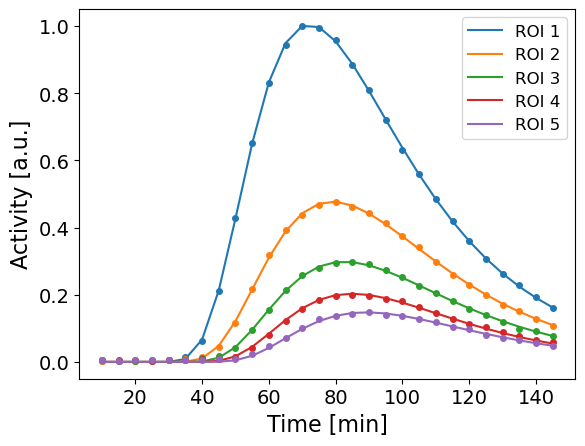

In [25]:
plot_pretty([0.35307084, 0.68079411, 0.63950353, 0.6255375 , 0.6400871 ,
       0.64628126, 0.64368471, 0.67228701, 0.37061246, 0.22291454,
       0.51082819, 0.51642038, 0.47939402, 0.96220357])

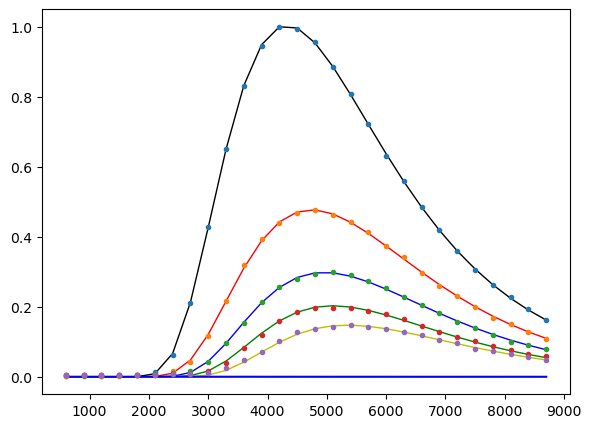

[7.70834596e-05 4.93940524e-03 1.68674167e-03 1.17278405e-03
 1.71255101e-03 2.01207379e-03 1.88061638e-03 5.49200761e-08
 9.22358342e-08 6.07178409e-09 5.54637089e-01 5.64778342e-07
 1.49024266e-01 1.92818678e+00] [-3.53155634e-03 -3.47484672e-03 -4.27753948e-03 -4.26588133e-03
 -5.03233264e-03 -3.82784655e-03 -3.83700643e-03 -3.34198423e-03
 -4.27034648e-03 -4.01809875e-03 -3.52971138e-03 -3.36319174e-03
 -3.88538426e-03 -4.29891417e-03 -4.35149585e-03 -3.90729911e-03
 -3.40101302e-03 -4.39359877e-03 -4.00689013e-03 -4.35966051e-03
 -4.69330539e-03 -5.77776550e-03 -5.18295319e-03 -4.63751993e-03
 -4.39123091e-03 -4.99921260e-03 -8.60065757e-03 -7.06604528e-03
 -5.51258194e-03 -5.73680658e-03  3.08065694e-03 -4.97695989e-03
 -1.06803984e-02 -7.71639286e-03 -6.68850891e-03  1.06828328e-03
  4.36437335e-03 -5.59025912e-03 -4.79577631e-03 -7.35074573e-03
 -7.81584037e-04  4.79543899e-03  2.60451964e-03  9.04569598e-04
 -5.23142101e-03 -2.15948101e-03 -1.61317203e-05 -8.48270226e-04
  4.7

In [65]:
x_best_fit = [0.35307084, 0.68079411, 0.63950353, 0.6255375 , 0.6400871 ,
       0.64628126, 0.64368471, 0.67228701, 0.37061246, 0.22291454,
       0.51082819, 0.51642038, 0.47939402, 0.96220357]

def compute_jacobian(f, x, eps=None):
    """Computes numerical Jacobian using central difference with adaptive epsilon."""
    x = np.asarray(x)
    n_params = len(x)
    f_x = np.asarray(f(x)).ravel()
    n_outputs = len(f_x)
    J = np.zeros((n_outputs, n_params))

    if eps is None:
        eps = np.sqrt(np.finfo(float).eps) * np.maximum(1.0, np.abs(x))

    for i in range(n_params):
        x_step = np.zeros_like(x)
        x_step[i] = eps[i]

        f_plus = np.asarray(f(x + x_step)).ravel()
        f_minus = np.asarray(f(x - x_step)).ravel()

        J[:, i] = (f_plus - f_minus) / (2 * eps[i])

    return J



# Compute the Jacobian
J = compute_jacobian(mct_obj_res, x_best_fit)

# Step 3: Compute the covariance matrix
JTJ_inv = np.linalg.pinv(J.T @ J)
sigma_squared = np.var(mct_obj_res(x_best_fit))  # Estimate variance of residuals
C = JTJ_inv * sigma_squared  # Covariance matrix

# Step 4: Compute parameter uncertainties
param_uncertainties = np.sqrt(np.abs(np.diag(C)))  # Extract uncertainties
rel_param_uncertanties = param_uncertainties / np.abs(x_best_fit)

# Print results
for i, uncertainty in enumerate(rel_param_uncertanties):
    print(f"Parameter {i}: ±{uncertainty*100}%")